In [1]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [2]:

expression_matrix = np.load('processed_expression_matrix.npy')
lineage_names = np.load('lineage_names.npy', allow_pickle=True)
selected_gene_names = np.load('selected_gene_names.npy', allow_pickle=True)
scaled_expression = expression_matrix.T  # Ensure it's in genes x lineages format
tree_lineage_names = pd.read_csv("./data/tree_lineage_names.txt", header=None).values.flatten() # lineage names from the 

In [3]:
# remove b'' from lineage_names
lineage_names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in lineage_names]

In [4]:
tree_lineage_names = list(set(tree_lineage_names).intersection(set(lineage_names)))

In [5]:
set(tree_lineage_names).difference(set(lineage_names))

set()

In [ ]:
# Find indices of tree_lineage_names in lineage_names
selected_indices = [lineage_names.index(name) for name in tree_lineage_names if name in lineage_names]

# Filter expression_matrix to include only selected lineages
filtered_expression_matrix = expression_matrix[selected_indices, :]

# Optionally, filter lineage_names as well for consistency
filtered_lineage_names = [lineage_names[i] for i in selected_indices]

expression_matrix = filtered_expression_matrix

In [71]:


print(f"Running UMAP on {expression_matrix.shape[0]} lineages with {expression_matrix.shape[1]} genes...")

# UMAP parameters for single-cell data
reducer = umap.UMAP(
    n_neighbors=20,          # Higher for more global structure
    min_dist=1.0,            # Controls how tightly points cluster
    n_components=2,          # 2D visualization
    metric='euclidean',      # Can also try 'cosine' or 'correlation'
    random_state=42,         # For reproducibility
    verbose=True
)

# Fit and transform
embedding = reducer.fit_transform(expression_matrix)
print(f"UMAP complete! Embedding shape: {embedding.shape}")

Running UMAP on 946 lineages with 3000 genes...
UMAP(min_dist=1.0, n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Tue Jun 17 16:48:47 2025 Construct fuzzy simplicial set


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Jun 17 16:48:48 2025 Finding Nearest Neighbors
Tue Jun 17 16:48:48 2025 Finished Nearest Neighbor Search
Tue Jun 17 16:48:48 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Jun 17 16:48:52 2025 Finished embedding
UMAP complete! Embedding shape: (946, 2)


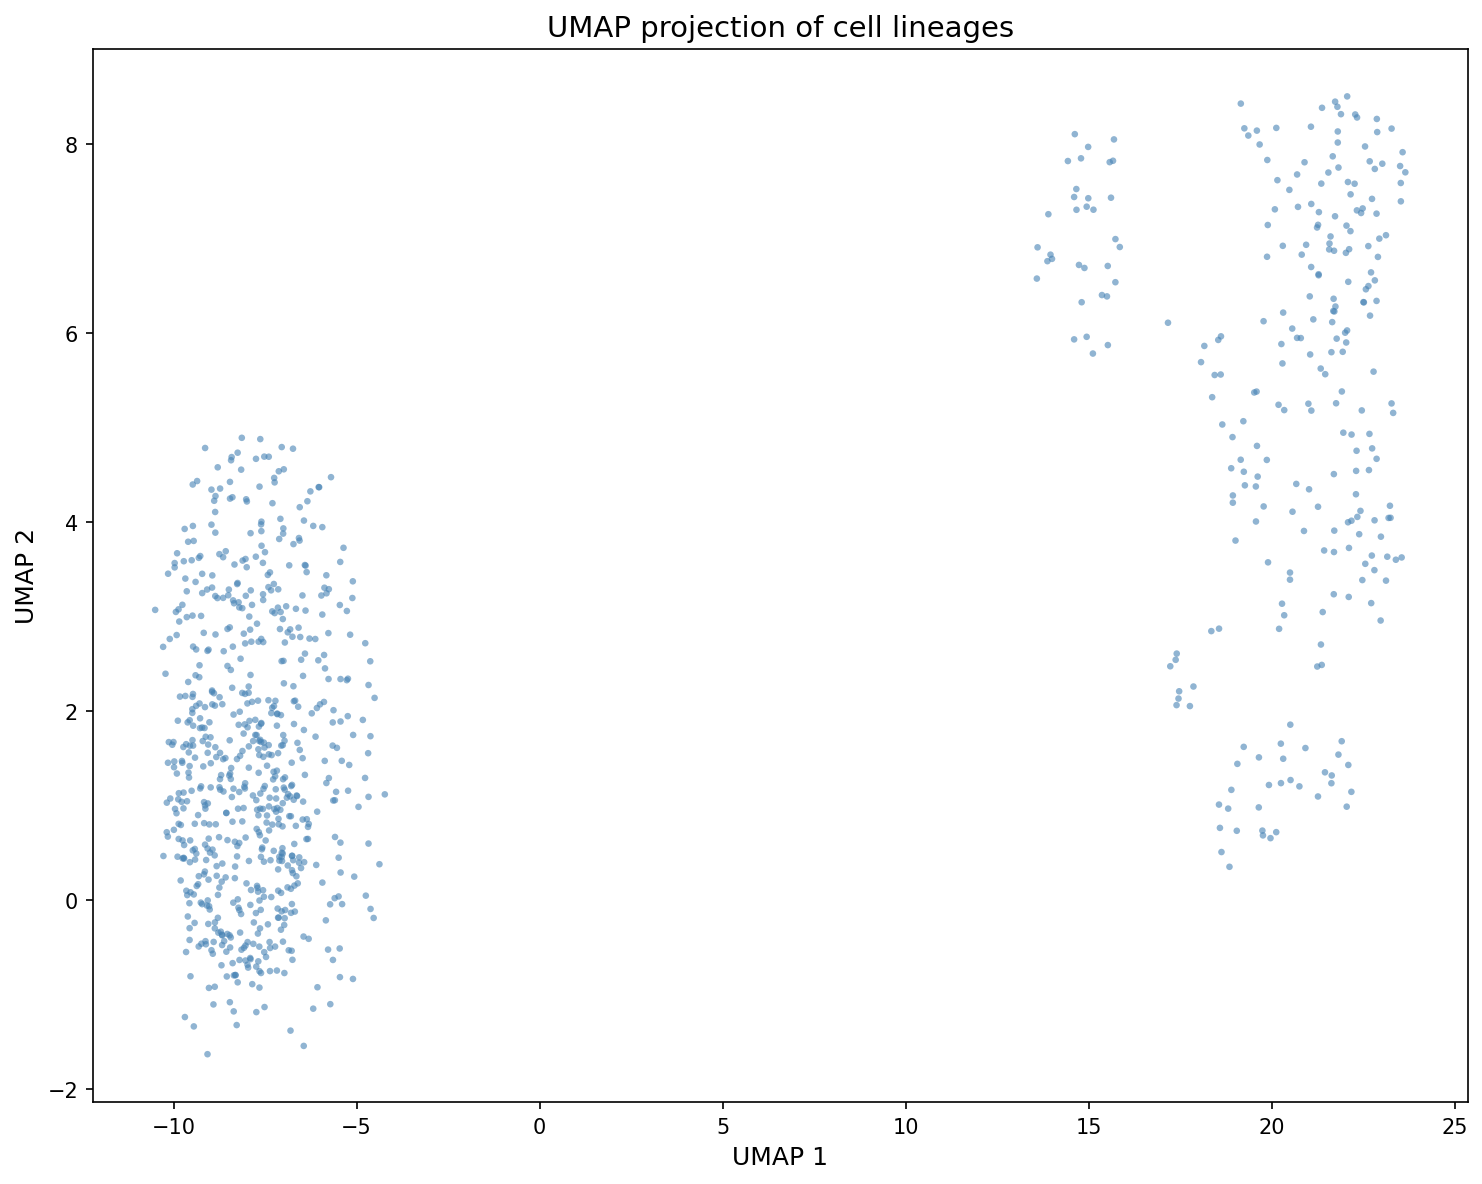

In [72]:
# Create figure with better size and resolution
plt.figure(figsize=(10, 8), dpi=150)

# Basic scatter plot
plt.scatter(embedding[:, 0], embedding[:, 1], 
           alpha=0.6, s=10, c='steelblue', edgecolors='none')

plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP projection of cell lineages', fontsize=14)
plt.tight_layout()
plt.show()

# Save the embedding
np.save('umap_embedding.npy', embedding)


Finding clusters with DBSCAN...
Found 3 clusters


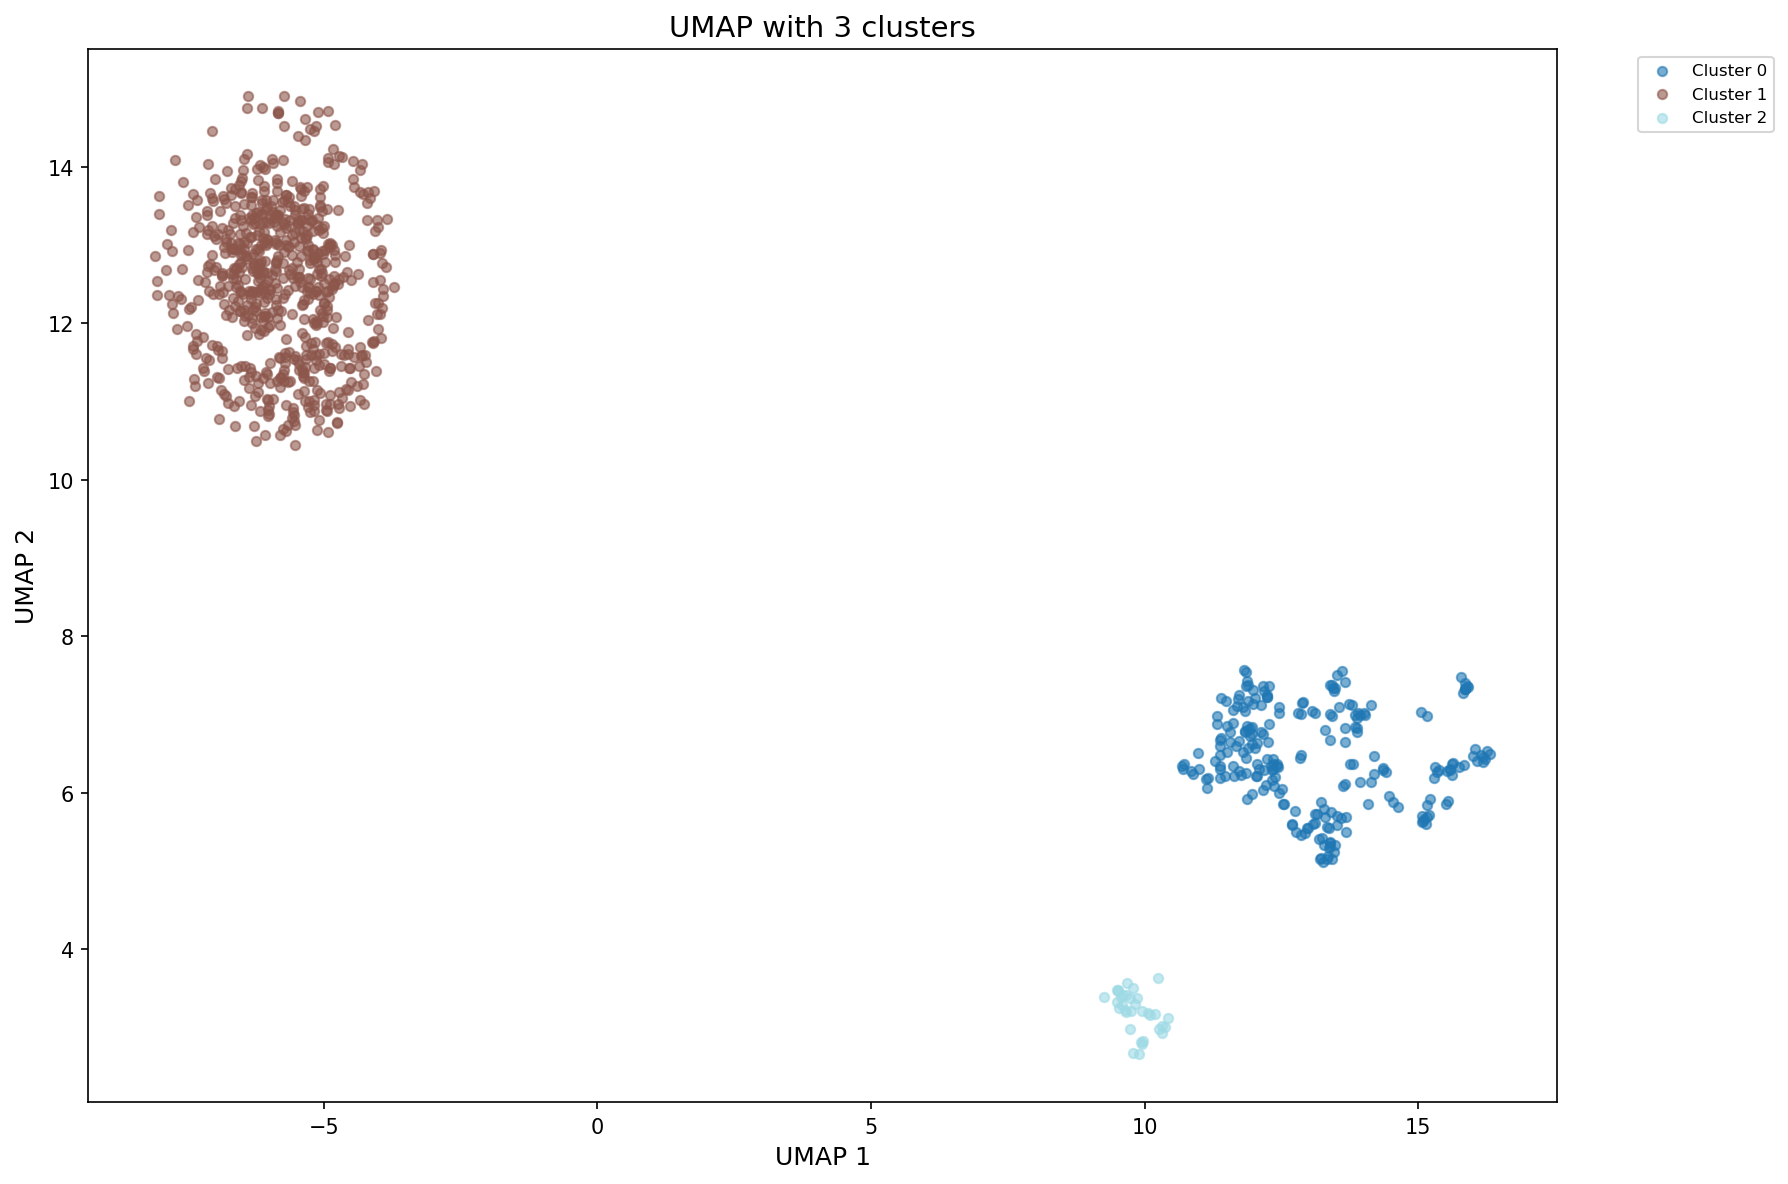

In [55]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Try DBSCAN for density-based clustering
print("\nFinding clusters with DBSCAN...")
clusterer = DBSCAN(eps=1.5, min_samples=5)
cluster_labels = clusterer.fit_predict(embedding)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Found {n_clusters} clusters")

# Alternative: KMeans for fixed number of clusters
# kmeans = KMeans(n_clusters=10, random_state=42)
# cluster_labels = kmeans.fit_predict(embedding)

# Visualize clusters
plt.figure(figsize=(12, 8), dpi=150)

# Create colormap
unique_labels = np.unique(cluster_labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    if label == -1:
        # Noise points in DBSCAN
        color = 'lightgray'
        label_name = 'Unclustered'
    else:
        color = colors[i]
        label_name = f'Cluster {label}'
    
    mask = cluster_labels == label
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
               c=[color], label=label_name, alpha=0.6, s=20)

plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title(f'UMAP with {n_clusters} clusters', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

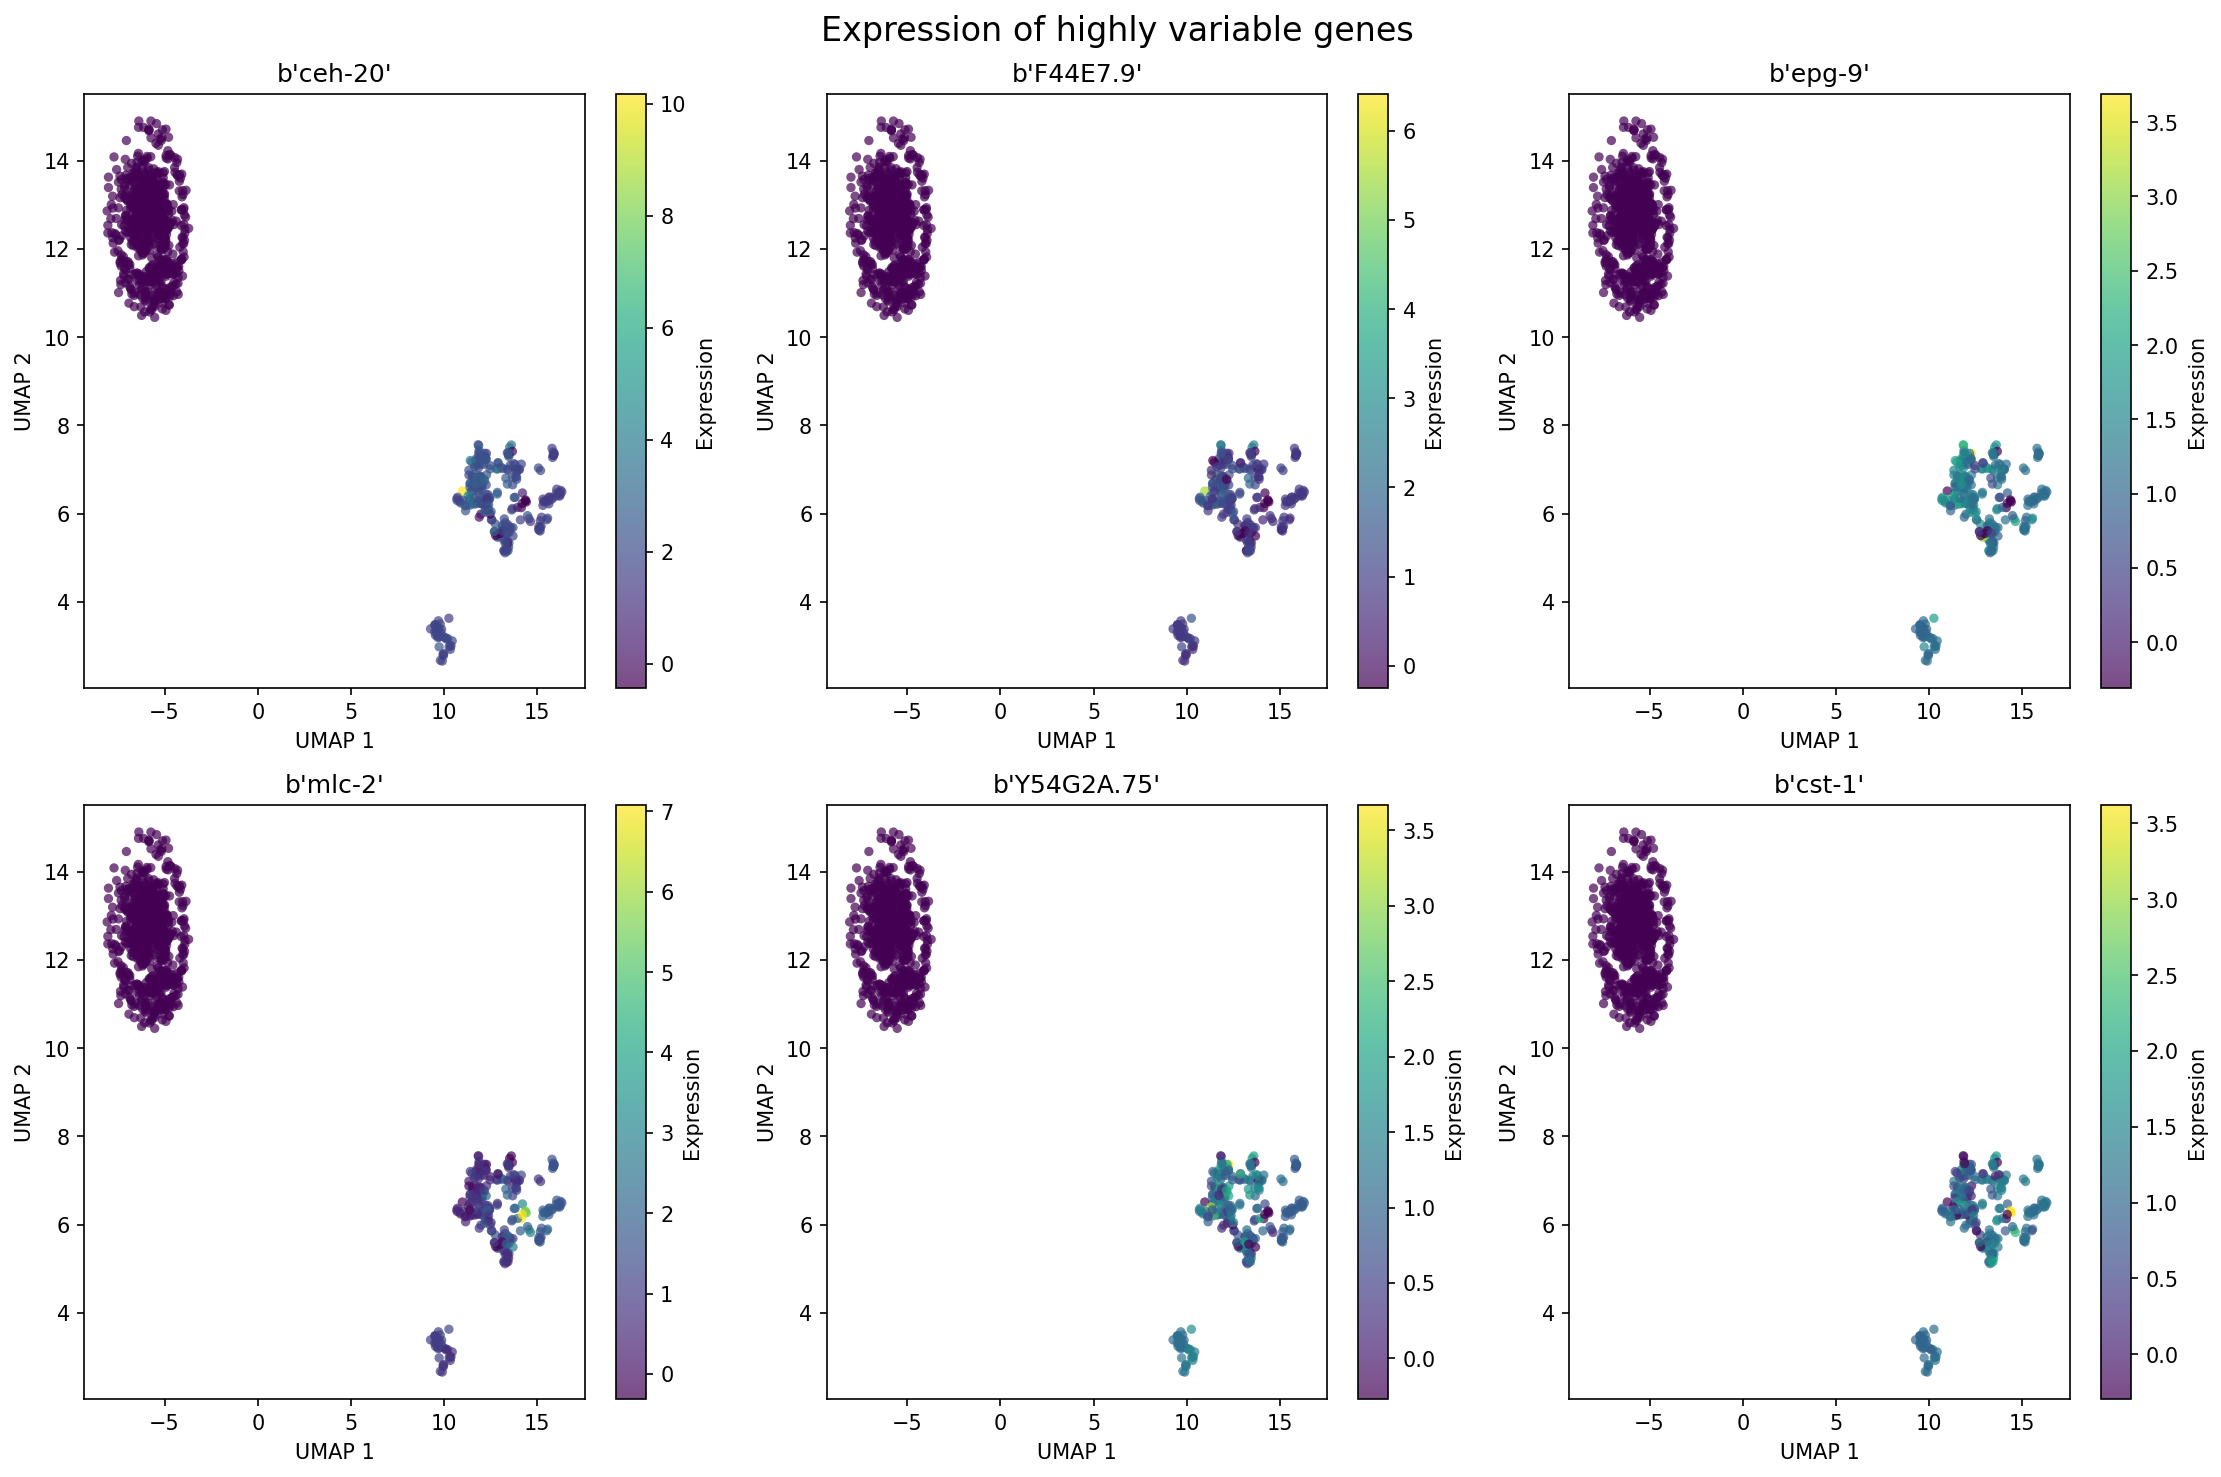

In [56]:
# Visualize expression of top genes
# Get indices of genes with highest variance in the scaled data
gene_vars_scaled = scaled_expression.var(axis=1)
top_var_genes_idx = np.argsort(gene_vars_scaled)[-6:]  # Top 6 genes

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=150)
axes = axes.flatten()

for i, gene_idx in enumerate(top_var_genes_idx):
    ax = axes[i]
    gene_name = selected_gene_names[gene_idx]
    gene_expr = expression_matrix[:, gene_idx]
    
    # Plot UMAP colored by gene expression
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], 
                        c=gene_expr, cmap='viridis', 
                        s=20, alpha=0.7, edgecolors='none')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'{gene_name}')
    plt.colorbar(scatter, ax=ax, label='Expression')

plt.suptitle('Expression of highly variable genes', fontsize=16)
plt.tight_layout()
plt.show()